In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("Setup complete!")

Setup complete!


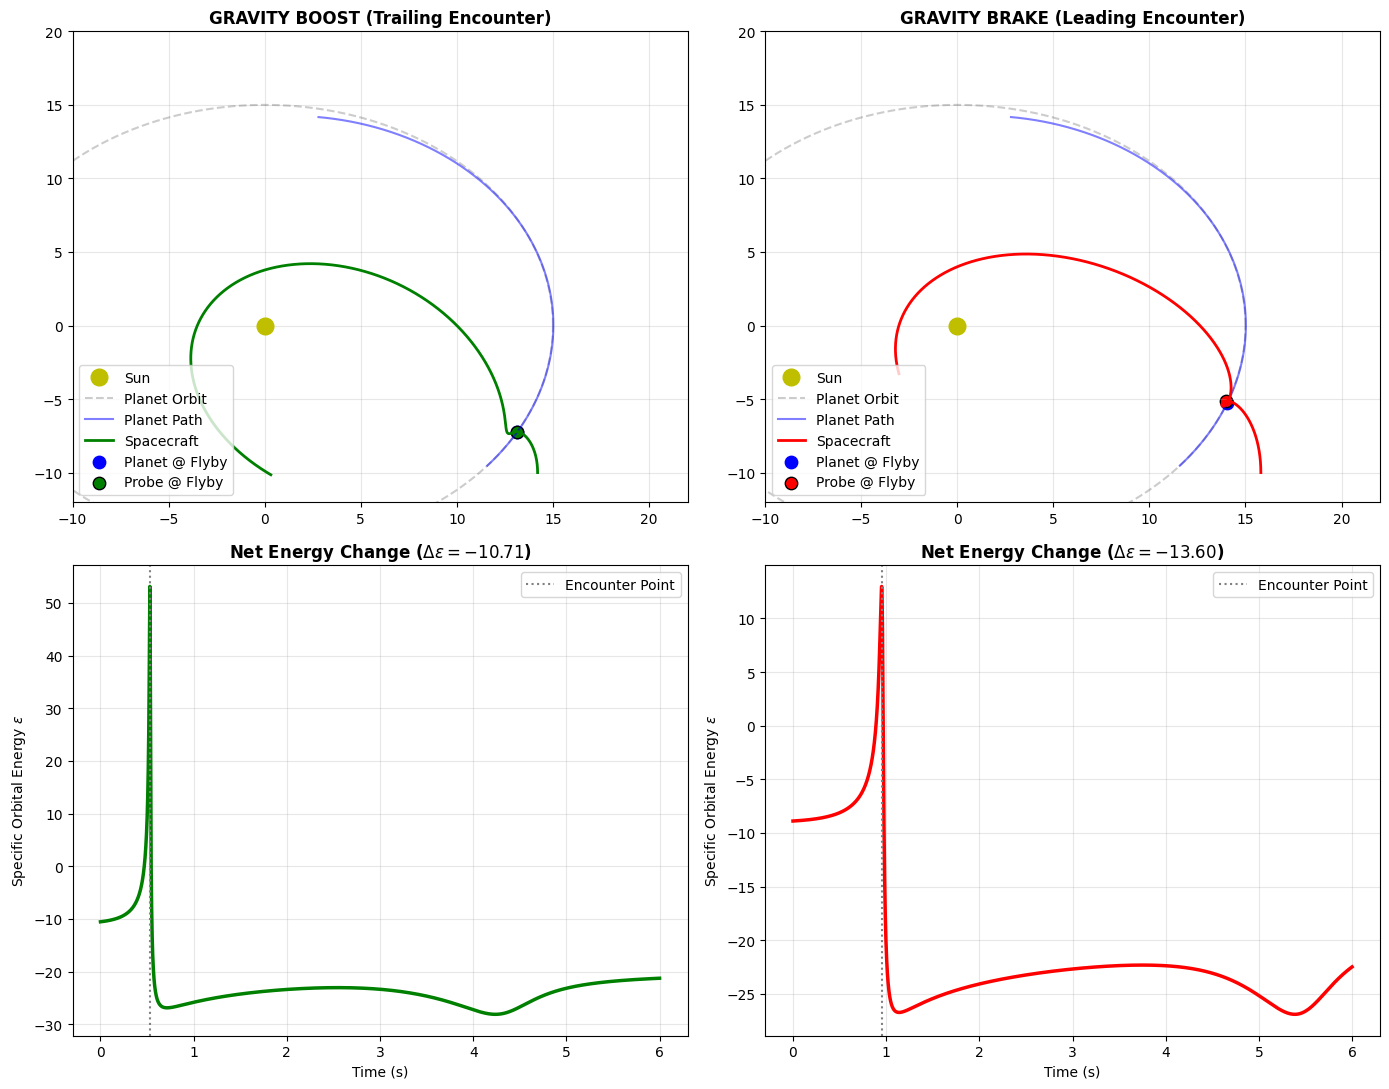

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def run_synchronized_assist(mode="boost"):
    # Physics parameters
    G = 1.0
    M_star = 400.0
    M_planet = 18.0
    m_probe = 0.01
    masses = np.array([M_star, M_planet, m_probe])

    # Planet orbit setup
    R_p = 15.0
    v_p_mag = np.sqrt(G * M_star / R_p)   # ~5.16
    omega = v_p_mag / R_p                # ~0.344 rad/s

    # Synchronize encounter at t = 2.0 seconds at (R_p, 0)
    t_encounter = 2.0
    theta_0 = - omega * t_encounter
    r_planet_0 = np.array([R_p * np.cos(theta_0), R_p * np.sin(theta_0)])
    v_planet_0 = np.array([-v_p_mag * np.sin(theta_0), v_p_mag * np.cos(theta_0)])

    # Spacecraft launch setup
    # Reaches y = 0 at t = 2.0 s with v_y = 5.0
    y_start = -10.0
    vy_start = 5.0

    if mode == "boost":
        # Trailing flyby: passes on the inside (x < R_p)
        x_start = 14.2
        vx_start = 0.0
        clr = 'green'
        title_str = "GRAVITY BOOST (Trailing Encounter)"
    else:
        # Leading flyby: passes on the outside (x > R_p)
        x_start = 15.8
        vx_start = 0.0
        clr = 'red'
        title_str = "GRAVITY BRAKE (Leading Encounter)"

    pos = np.array([[0.0, 0.0], r_planet_0, [x_start, y_start]], dtype=float)
    vel = np.array([[0.0, 0.0], v_planet_0, [vx_start, vy_start]], dtype=float)

    dt = 0.0005
    t_max = 6.0
    num_steps = int(t_max / dt)

    probe_pos = np.zeros((num_steps, 2))
    planet_pos = np.zeros((num_steps, 2))
    energy_probe = np.zeros(num_steps)
    dist_to_planet = np.zeros(num_steps)

    for step in range(num_steps):
        probe_pos[step] = pos[2]
        planet_pos[step] = pos[1]

        r_star = np.linalg.norm(pos[2] - pos[0])
        dist_to_planet[step] = np.linalg.norm(pos[2] - pos[1])

        # Heliocentric Specific Orbital Energy: E = 1/2 v^2 - G*M/r
        speed_sq = np.sum(vel[2]**2)
        energy_probe[step] = 0.5 * speed_sq - (G * M_star / r_star)

        # 3-body gravitational interactions
        acc = np.zeros_like(pos)
        for i in range(3):
            for j in range(i + 1, 3):
                r_vec = pos[j] - pos[i]
                r_dist = np.linalg.norm(r_vec) + 0.05  # Softening factor
                f_mag = G * masses[i] * masses[j] / (r_dist**3)
                acc[i] += f_mag * r_vec / masses[i]
                acc[j] -= f_mag * r_vec / masses[j]

        vel += acc * dt
        pos += vel * dt

    idx_enc = np.argmin(dist_to_planet)
    return probe_pos, planet_pos, energy_probe, idx_enc, clr, title_str

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
time_arr = np.linspace(0, 6.0, int(6.0/0.0005))

for col, mode in enumerate(["boost", "brake"]):
    probe_p, planet_p, E_p, enc_idx, clr, ttl = run_synchronized_assist(mode)

    # Trajectory plots
    axes[0, col].plot(0, 0, 'yo', markersize=12, label="Sun")
    theta_ring = np.linspace(0, 2*np.pi, 200)
    axes[0, col].plot(15*np.cos(theta_ring), 15*np.sin(theta_ring), 'k--', alpha=0.2, label="Planet Orbit")
    axes[0, col].plot(planet_p[:, 0], planet_p[:, 1], 'b-', alpha=0.5, label="Planet Path")
    axes[0, col].plot(probe_p[:, 0], probe_p[:, 1], clr, linewidth=2, label="Spacecraft")

    # Flyby encounter markers
    axes[0, col].scatter(planet_p[enc_idx, 0], planet_p[enc_idx, 1], color='blue', s=80, label="Planet @ Flyby")
    axes[0, col].scatter(probe_p[enc_idx, 0], probe_p[enc_idx, 1], color=clr, s=80, edgecolors='black', label="Probe @ Flyby")

    axes[0, col].set_title(ttl, fontweight="bold")
    axes[0, col].set_xlim(-10, 22)
    axes[0, col].set_ylim(-12, 20)
    axes[0, col].legend(loc="lower left")
    axes[0, col].grid(True, alpha=0.3)

    # Orbital energy step plots
    delta_E = E_p[-1] - E_p[0]
    axes[1, col].plot(time_arr, E_p, clr, linewidth=2.5)
    axes[1, col].axvline(time_arr[enc_idx], color='gray', linestyle=':', label="Encounter Point")
    axes[1, col].set_title(f"Net Energy Change ($\\Delta \\epsilon = {delta_E:+.2f}$)", fontweight="bold")
    axes[1, col].set_xlabel("Time (s)")
    axes[1, col].set_ylabel("Specific Orbital Energy $\\epsilon$")
    axes[1, col].legend()
    axes[1, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()